# Titanic Survival Prediction — End-to-End ML Pipeline

**Goal:** Build a complete, working machine learning pipeline using the classic Titanic dataset —
from raw data to an evaluated model.

**Workflow:**
1. Load & explore the data
2. Handle missing values & encode categorical features
3. Split into train/test sets
4. Train a scikit-learn classifier (Logistic Regression + Decision Tree)
5. Evaluate using accuracy, confusion matrix, and precision/recall

Every step includes a short markdown explanation in plain words, so this notebook also works as a learning record.


## 0. Setup

We start by importing the libraries we'll need: `pandas` for data handling, `numpy` for numeric
operations, and `scikit-learn` for preprocessing, modeling, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", None)
np.random.seed(42)


## 1. Data Exploration (20%)

We load the Titanic dataset directly from a public URL (the same dataset used on Kaggle), so this
notebook runs end-to-end in Google Colab with zero local setup.

**What we're looking for here:**
- What columns exist, and what do they mean?
- How many rows do we have?
- Are there missing values?
- What's the overall survival rate, and does it vary by obvious factors like sex or class?


In [2]:
# Titanic dataset (public mirror, same data as Kaggle's train.csv)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Column meanings (for reference):**

| Column | Meaning |
|---|---|
| `Survived` | 0 = No, 1 = Yes (this is our target) |
| `Pclass` | Ticket class (1st, 2nd, 3rd) — a proxy for socio-economic status |
| `Sex` | Passenger's sex |
| `Age` | Age in years |
| `SibSp` | # of siblings/spouses aboard |
| `Parch` | # of parents/children aboard |
| `Fare` | Ticket fare |
| `Embarked` | Port of embarkation (C, Q, S) |
| `Cabin` | Cabin number (mostly missing) |


In [3]:
# Basic info: data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Summary statistics for numeric columns
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0
Cabin,687
Age,177
Embarked,2


**Observation:** `Cabin` is missing for most rows, `Age` has a noticeable number of gaps, and
`Embarked` is missing for just a couple of rows. We'll handle each of these in the preprocessing step.


In [6]:
# Overall survival rate
print(f"Overall survival rate: {df['Survived'].mean():.2%}")

# Survival rate by sex and by class — quick sanity check that the data behaves as expected
print("\nSurvival rate by Sex:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean())


Overall survival rate: 38.38%

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


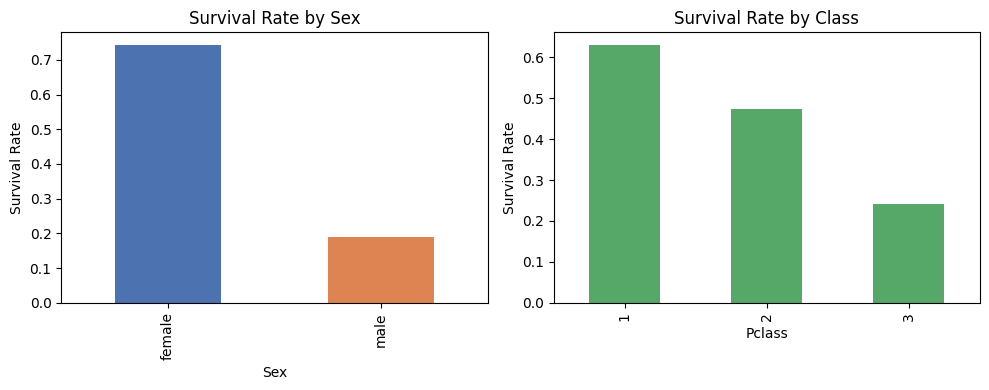

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], title='Survival Rate by Sex', color=['#4c72b0', '#dd8452'])
axes[0].set_ylabel('Survival Rate')

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], title='Survival Rate by Class', color='#55a868')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()


**Takeaway:** Women and first-class passengers survived at much higher rates. This matches
the historical "women and children first" evacuation policy, and confirms `Sex` and `Pclass` are
likely to be strong predictive features.


## 2. Data Preprocessing (25%)

Raw data isn't ready for a model. We need to:
1. Drop columns that aren't useful or are mostly missing (`Cabin`, `Name`, `Ticket`, `PassengerId`)
2. Fill missing values (`Age`, `Embarked`)
3. Encode categorical columns (`Sex`, `Embarked`) into numbers, since scikit-learn models only accept numeric input
4. Select our final feature set


In [8]:
# Work on a copy so the original df stays untouched for reference
data = df.copy()

# Drop columns that are identifiers or too sparse to be useful without heavy feature engineering
data = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Fill missing Age with the median (robust to outliers, simple and effective baseline choice)
data['Age'] = data['Age'].fillna(data['Age'].median())

# Fill missing Embarked with the mode (most common port)
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Confirm no missing values remain
data.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [9]:
# Encode categorical features numerically
# Sex: male/female -> 0/1
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# Embarked: one-hot encode since there's no natural order among C/Q/S
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

data.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


**Why these choices?**
- Median imputation for `Age` avoids letting a few extreme ages skew the fill value.
- `Sex` is binary, so a simple 0/1 mapping is enough — no need for one-hot encoding.
- `Embarked` has 3 unrelated categories, so one-hot encoding (`drop_first=True` to avoid redundancy)
  is more appropriate than assigning arbitrary numbers, which would imply a false order.


In [10]:
# Separate features (X) and target (y)
X = data.drop(columns=['Survived'])
y = data['Survived']

print("Feature columns:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)


Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
X shape: (891, 8) | y shape: (891,)


## 3. Train/Test Split

We hold out 20% of the data as a test set the model never sees during training. This lets us
estimate how well the model generalizes to new passengers, instead of just memorizing the training
data. We use `stratify=y` so the survival rate is preserved in both splits.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train survival rate:", y_train.mean().round(3))
print("Test survival rate:", y_test.mean().round(3))


Train size: 712
Test size: 179
Train survival rate: 0.383
Test survival rate: 0.385


We'll also scale the numeric features. This isn't strictly required for a Decision Tree, but
it matters for Logistic Regression, which is sensitive to feature scale.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit only on train to avoid leaking test info


## 4. Model Training & Evaluation (25%)

We train two classifiers so we can compare a simple linear model against a simple non-linear one:

- **Logistic Regression** — a strong, interpretable baseline for binary classification
- **Decision Tree** — captures non-linear patterns and feature interactions, no scaling required


In [13]:
# --- Model 1: Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# --- Model 2: Decision Tree ---
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)  # trees don't need scaled features
y_pred_tree = tree_clf.predict(X_test)

print("Both models trained.")


Both models trained.


### Evaluation metrics

- **Accuracy**: overall % of correct predictions. Simple, but can be misleading on imbalanced data.
- **Confusion matrix**: breaks predictions into true/false positives and negatives — shows *what kind*
  of mistakes the model makes.
- **Precision**: of everyone the model predicted as "survived," how many actually did? High precision
  means few false alarms.
- **Recall**: of everyone who actually survived, how many did the model correctly catch? High recall
  means few missed survivors.


In [14]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print()
    return acc, prec, rec

log_metrics = evaluate("Logistic Regression", y_test, y_pred_log)
tree_metrics = evaluate("Decision Tree", y_test, y_pred_tree)


--- Logistic Regression ---
Accuracy:  0.804
Precision: 0.793
Recall:    0.667

--- Decision Tree ---
Accuracy:  0.777
Precision: 0.754
Recall:    0.623



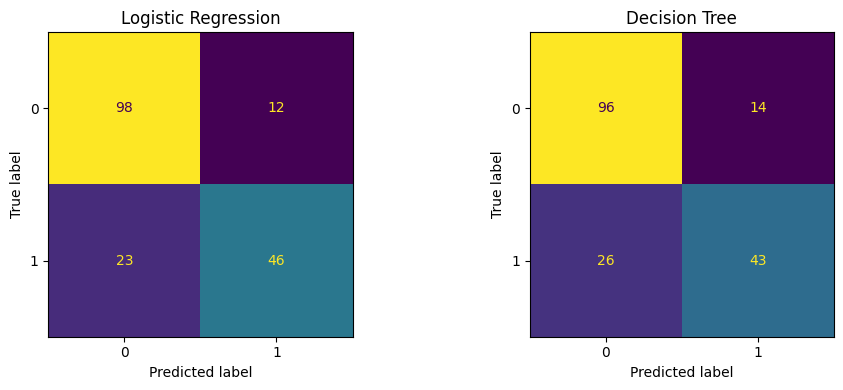

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()


In [16]:
print("Logistic Regression — full report:")
print(classification_report(y_test, y_pred_log, target_names=["Did not survive", "Survived"]))

print("Decision Tree — full report:")
print(classification_report(y_test, y_pred_tree, target_names=["Did not survive", "Survived"]))


Logistic Regression — full report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179

Decision Tree — full report:
                 precision    recall  f1-score   support

Did not survive       0.79      0.87      0.83       110
       Survived       0.75      0.62      0.68        69

       accuracy                           0.78       179
      macro avg       0.77      0.75      0.76       179
   weighted avg       0.77      0.78      0.77       179



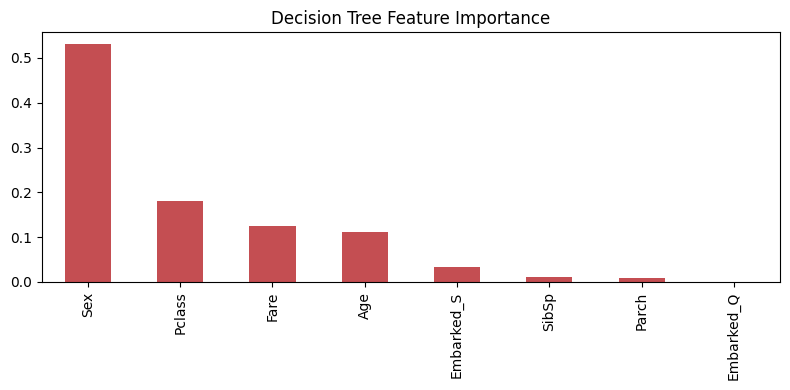

,0
Sex,0.530655
Pclass,0.180404
Fare,0.124532
Age,0.111294
Embarked_S,0.034252
SibSp,0.011150
Parch,0.007714
Embarked_Q,0.000000


In [17]:
# Which features mattered most to the Decision Tree?
importances = pd.Series(tree_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(8, 4), title='Decision Tree Feature Importance', color='#c44e52')
plt.tight_layout()
plt.show()
importances


**Comparing the two models:** the printed metrics and confusion matrices above tell the real
story on this run — compare the two `accuracy` / `precision` / `recall` numbers directly rather
than assuming one is better. In general, Logistic Regression tends to be the steadier baseline
here, while the Decision Tree can pick up non-linear patterns (like the `Sex`/`Pclass` interaction)
but is more prone to overfitting if `max_depth` is too high.


## 5. Documentation & Code Clarity (15%)

This notebook follows a consistent structure: each step (explore → preprocess → split → train →
evaluate) has its own section with a markdown explanation *before* the code, describing the "why"
behind each decision — not just the "what." Variable names (`X_train`, `y_pred_tree`, etc.) follow
scikit-learn conventions so the code is easy to follow even without the surrounding text.


## 6. Reflection & Next Steps (15%)

**What I learned:**
- The core ML loop is: load data → clean/encode it → split it → fit a model → measure how well it did.
- Preprocessing decisions (how to fill missing values, how to encode categories) aren't neutral —
  they encode assumptions that can affect model performance.
- A model's accuracy alone doesn't tell the whole story; precision and recall reveal *what kind*
  of mistakes it makes, which matters a lot depending on the use case.

**What I'd try next, if I kept going:**
- Feature engineering: extract titles (Mr/Mrs/Miss) from the `Name` column, or combine `SibSp` +
  `Parch` into a `FamilySize` feature.
- Try other models (Random Forest, Gradient Boosting) and compare with cross-validation instead of
  a single train/test split.
- Tune hyperparameters (e.g. `max_depth`, `C` in Logistic Regression) with `GridSearchCV`.
- Now that this loop is solid, apply the same pipeline structure to my overdue "Basic End-to-End
  Machine Learning Pipeline" task, and later to the RAG chatbot tasks, which need the same
  discipline of "get clean input in, evaluate output quality" — just with different data and models.
